#### 1. Data Loading & Date Parsing
* In this section, I load the raw CSV and perform feature engineering. I combine the YEAR and DOY (Day of Year) into a single Date column using the %Y%j format. This conversion is critical for time-series analysis, as it allows Pandas to recognize the chronological order of the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Force charts to render in the notebook
%matplotlib inline
plt.ion() 

df = pd.read_csv("../data/tanzaniya.csv")
df["Country"] = "Tanzaniya"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month

print("Data Loading Successful!")
print(f"New Date range: {df['Date'].min()} to {df['Date'].max()}")
df[['Country', 'YEAR', 'DOY', 'Date', 'Month']].head()

Data Loading Successful!
New Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,Country,YEAR,DOY,Date,Month
0,Ethiopia,2015,1,2015-01-01,1
1,Ethiopia,2015,2,2015-01-02,1
2,Ethiopia,2015,3,2015-01-03,1
3,Ethiopia,2015,4,2015-01-04,1
4,Ethiopia,2015,5,2015-01-05,1


###  2. Summary Statistics & Missing-Value Report
* In this section, we sanitize the data by handling NASA's sentinel values and removing redundancies to ensure statistical integrity.

#### 2.1 Handling Sentinels and Duplicates
* NASA Power data uses -999 as a placeholder for missing or invalid observations. We must replace these with NaN (Not a Number) to ensure they are excluded from calculations like Mean and Standard Deviation. We also perform a check for duplicate rows to prevent data inflation.

In [35]:
df.replace(-999, np.nan, inplace=True)

duplicate_total = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_total}")
if duplicate_total > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been successfully removed.")

Total duplicate rows found: 0


#### 2.2 Descriptive Statistics
* The table below provides the statistical profile of our climate variables. Key metrics such as the mean temperature ($T2M$) and maximum precipitation ($PRECTOTCORR$) give us an initial look at the climate extremes in the region.

In [36]:
stats_summary = df.describe()
stats_summary

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


#### 2.3 Missing Value Analysis
* Data quality is assessed by calculating the percentage of null values. According to our project constraints, any column with more than 5% missing data requires special attention or potential exclusion to maintain the validity of the COP32 report.

In [37]:
null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

print("Missing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])

high_nulls = null_percentages[null_percentages > 5]
if not high_nulls.empty:
    print(f"\nWARNING: The following columns have > 5% nulls: \n{high_nulls}")
else:
    print("\nQuality Check Passed: No columns exceed the 5% missing value threshold.")

Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

Quality Check Passed: No columns exceed the 5% missing value threshold.


### 3. Outlier Detection & Basic Cleaning
* In this section, we identify statistical anomalies and finalize the dataset for analysis and export.

In [ ]:
from scipy import stats
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[weather_cols], nan_policy='omit'))
outlier_rows = (z_scores > 3).any(axis=1)
flagged_count = outlier_rows.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {flagged_count}")
print("\nOutlier breakdown by column:")
print((z_scores > 3).sum())

threshold = len(df.columns) * 0.7
df.dropna(thresh=threshold, inplace=True)
df[weather_cols] = df[weather_cols].ffill()
print(f"Cleaning complete. Remaining rows: {len(df)}")


Total rows flagged as outliers (|Z| > 3): 132

Outlier breakdown by column:
137
Cleaning complete. Remaining rows: 4108
Successfully exported cleaned data to: ../data/ethiopia_clean.csv


### 4. Time Series Analysis
* In this section, we analyze the temporal trends of temperature and precipitation for Ethiopia. By identifying the extremes (warmest/coolest months) and the peak rainy seasons, we can better understand the regional climate shifts.

#####  4.1 Monthly Temperature Trends (Line Chart)
* The line chart below illustrates the monthly average temperature ($T2M$) from 2015 to 2026. This visualization highlights the seasonal variability of the Ethiopian climate. We have annotated the absolute warmest and coolest months to pinpoint the historical extremes over the last decade.

#### 4.2 Monthly Total Precipitation (Bar Chart)
* This bar chart displays the total monthly precipitation ($PRECTOTCORR$). Aggregating by total rainfall is essential for identifying the intensity of the rainy seasons. The peak rainy months (typically July and August for Ethiopia) are annotated to show the periods of highest flood risk and agricultural productivity.

#### 4.3 Distribution of Rainfall (Histogram)
* We use a histogram with a log-scaled y-axis to analyze the frequency of precipitation events. Because many days experience zero or very low rainfall, the log scale is necessary to visualize the 'long tail'—the rare but significant heavy rainfall events that can lead to flooding.


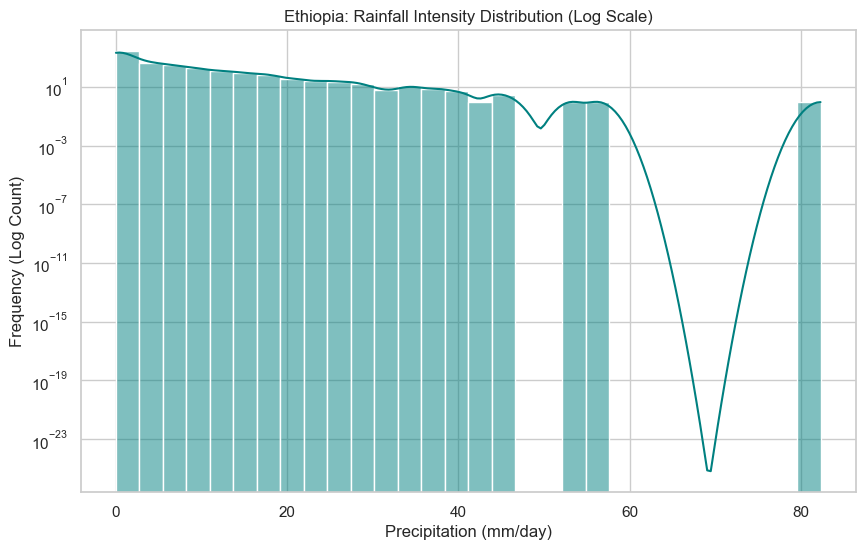

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'].dropna(), bins=30, kde=True, color='teal')
plt.yscale('log') 
plt.title("Ethiopia: Rainfall Intensity Distribution (Log Scale)")
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Log Count)")
plt.show()

#### 4.4 Variable Relationship Analysis (Scatter Plot)
* This scatter plot explores the bivariate relationship between Temperature ($T2M$) and Relative Humidity ($RH2M$). We have included a regression trend line (in red) to statistically confirm the inverse relationship: as temperatures rise, humidity levels typically drop, increasing the risk of agricultural drought.

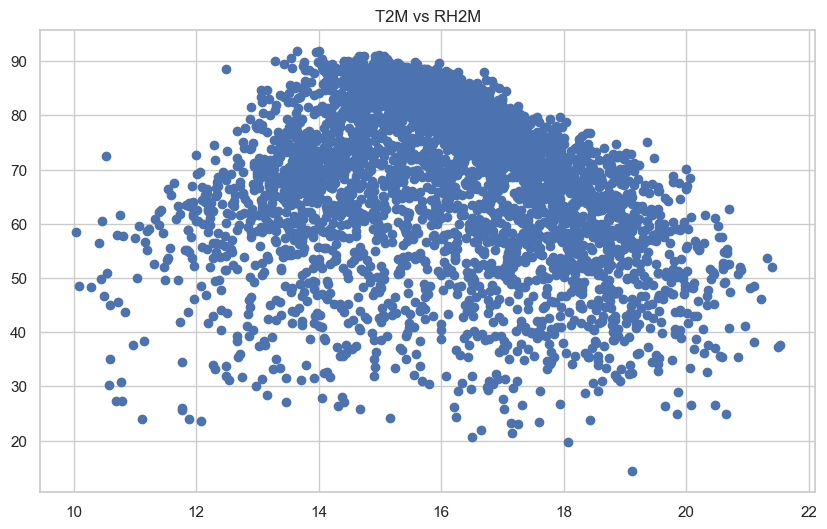

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(df["T2M"],df["RH2M"])
plt.title("T2M vs RH2M")
plt.show()

### 5. Exporting Clean Data
* The final cleaned dataset is exported to a CSV file. This file is excluded from version control via .gitignore to ensure we only host the analysis code on GitHub.




In [16]:
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Data cleaning complete and exported.")

Data cleaning complete and exported.
